## PyTorch Tabular Models — Seattle Airbnb price prediction

Three differentiable models designed for downstream **multi-modal fusion** with text and image modalities.
Every model exposes `.encode(x) → Tensor[B, embed_dim]` for later concatenation:

```python
fused = torch.cat([tab_emb, txt_emb, img_emb], dim=1)
pred  = fusion_head(fused)
```

| # | Model | Architecture | embed_dim |
|---|---|---|---|
| 1 | LinearTabular | Single linear layer | n_features (159) |
| 2 | MLPTabular | BN → GELU → Dropout blocks (256→128→64) | 64 |
| 3 | ResNetTabular | Residual blocks with 4× expansion | 128 |

**Target:** `log_price = log(price)` from `data/raw/target.csv` (Person B).  
**Features:** `data/processed/tabular_train.csv` / `tabular_test.csv` (51 cols, 0 NaN).  
**Split strategy:** 80 % train / 20 % validation (for early stopping); test set reserved for final one-time evaluation.

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

from src.tabular.torch_models import (
    FeatureEncoder,
    LinearTabular,
    MLPTabular,
    ResNetTabular,
    train_model,
    evaluate_model,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Load data and target

In [2]:
df_train_raw = pd.read_csv("../data/processed/tabular_train.csv")
df_test_raw  = pd.read_csv("../data/processed/tabular_test.csv")
target       = pd.read_csv("../data/raw/target.csv").set_index("id")

train_ids = df_train_raw["id"].values
test_ids  = df_test_raw["id"].values

y_train_full = target.loc[train_ids, "log_price"].values.astype(np.float32)
y_test       = target.loc[test_ids,  "log_price"].values.astype(np.float32)

print(f"Train : {len(df_train_raw):,} rows")
print(f"Test  : {len(df_test_raw):,} rows")
print(f"Target: log_price in [{y_train_full.min():.2f}, {y_train_full.max():.2f}]  "
      f"(median {np.median(y_train_full):.2f})")

Train : 4,926 rows
Test  : 1,232 rows
Target: log_price in [2.71, 7.45]  (median 4.99)


## Feature encoding — 80 / 20 train / val split

`FeatureEncoder` is stateful: it must be **fit on training data only** to prevent leakage.  
The 20 % validation split is used solely for early stopping; it is **not** the test set.

In [3]:
idx = np.arange(len(df_train_raw))
tr_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_tr_df  = df_train_raw.iloc[tr_idx].reset_index(drop=True)
X_val_df = df_train_raw.iloc[val_idx].reset_index(drop=True)
y_tr     = y_train_full[tr_idx]
y_val    = y_train_full[val_idx]

encoder  = FeatureEncoder()
X_tr     = encoder.fit_transform(X_tr_df)    # fit on 80 % train only
X_val    = encoder.transform(X_val_df)
X_test   = encoder.transform(df_test_raw)

print(f"Encoded feature dimension : {encoder.n_features}")
print(f"Train split (80 %)        : {len(X_tr):,} rows")
print(f"Val   split (20 %)        : {len(X_val):,} rows")
print(f"Test                      : {len(X_test):,} rows")

Encoded feature dimension : 158
Train split (80 %)        : 3,940 rows
Val   split (20 %)        : 986 rows
Test                      : 1,232 rows


## 1. LinearTabular

Single `nn.Linear(n_features → 1)`. `encode()` returns the scaled input itself (embed_dim = n_features).  
The head bias is initialised to `y_tr.mean()` so gradient descent starts from the dummy baseline (MSE ≈ 0.34) rather than from zero (MSE ≈ 25), which would cause CosineAnnealingLR to decay the LR before the bias can move.

In [4]:
y_mean = float(y_tr.mean())
linear_model = LinearTabular(encoder.n_features, bias_init=y_mean)

linear_history = train_model(
    linear_model, X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=256, lr=1e-3,
    weight_decay=1e-4, patience=10,
    device=DEVICE, verbose=True,
)
print(f"\nBest epoch: {linear_history['best_epoch']}  "
      f"best val RMSE: {linear_history['best_val_rmse']:.4f}")

  epoch   1/100  train=0.5134  val=0.4139
  epoch  10/100  train=0.1021  val=0.1063
  epoch  20/100  train=0.0923  val=0.1010


  epoch  30/100  train=0.0909  val=0.1006
  Early stop at epoch 34  (best epoch=24)

Best epoch: 24  best val RMSE: 0.3169


In [5]:
print("── LinearTabular evaluation ──────────────────────────────────")
linear_val_m  = evaluate_model(linear_model, X_val,  y_val,  "LinearTabular val",  DEVICE)
linear_test_m = evaluate_model(linear_model, X_test, y_test, "LinearTabular test", DEVICE)

── LinearTabular evaluation ──────────────────────────────────
[LinearTabular val]         RMSE log=0.3169  MAE log=0.2382  R²=0.7086
                            RMSE $=        85  MAE $=        44  MedAE $=        26  MAPE=24.3%
[LinearTabular test]        RMSE log=0.3340  MAE log=0.2488  R²=0.6648
                            RMSE $=        99  MAE $=        50  MedAE $=        27  MAPE=24.7%


## 2. MLPTabular

Three `[Linear → BatchNorm1d → GELU → Dropout]` blocks: 256 → 128 → 64.  
`encode()` returns the 64-dimensional output of the last block.

In [6]:
mlp_model = MLPTabular(encoder.n_features, hidden_dims=(256, 128, 64), dropout=0.2)

mlp_history = train_model(
    mlp_model, X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=256, lr=1e-3,
    weight_decay=1e-4, patience=10,
    device=DEVICE, verbose=True,
)
print(f"\nBest epoch: {mlp_history['best_epoch']}  "
      f"best val RMSE: {mlp_history['best_val_rmse']:.4f}")

  epoch   1/100  train=23.3204  val=23.2036


  epoch  10/100  train=2.4483  val=1.9993


  epoch  20/100  train=0.5129  val=0.1691


  epoch  30/100  train=0.4358  val=0.1557


  epoch  40/100  train=0.3981  val=0.1261


  epoch  50/100  train=0.3601  val=0.1254


  Early stop at epoch 59  (best epoch=49)

Best epoch: 49  best val RMSE: 0.3289


In [7]:
print("── MLPTabular evaluation ─────────────────────────────────────")
mlp_val_m  = evaluate_model(mlp_model, X_val,  y_val,  "MLPTabular val",  DEVICE)
mlp_test_m = evaluate_model(mlp_model, X_test, y_test, "MLPTabular test", DEVICE)

── MLPTabular evaluation ─────────────────────────────────────
[MLPTabular val]            RMSE log=0.3289  MAE log=0.2427  R²=0.6861
                            RMSE $=        88  MAE $=        45  MedAE $=        26  MAPE=23.5%
[MLPTabular test]           RMSE log=0.3529  MAE log=0.2550  R²=0.6257
                            RMSE $=       100  MAE $=        50  MedAE $=        27  MAPE=24.4%


## 3. ResNetTabular

`Linear(n → 128)` → 4 × residual blocks (4× expansion, LayerNorm, GELU, Dropout) → `Linear(128 → 1)`.  
Each block refines the representation by learning the residual left by all preceding blocks — analogous to gradient boosting.  
`encode()` returns the 128-dimensional output of the final block.

In [8]:
resnet_model = ResNetTabular(encoder.n_features, d_model=128, n_blocks=4, dropout=0.15)

resnet_history = train_model(
    resnet_model, X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=256, lr=1e-3,
    weight_decay=1e-4, patience=10,
    device=DEVICE, verbose=True,
)
print(f"\nBest epoch: {resnet_history['best_epoch']}  "
      f"best val RMSE: {resnet_history['best_val_rmse']:.4f}")

  epoch   1/100  train=5.6295  val=1.2247


  epoch  10/100  train=0.0950  val=0.1074


  epoch  20/100  train=0.0666  val=0.1032


  Early stop at epoch 28  (best epoch=18)

Best epoch: 18  best val RMSE: 0.3154


In [9]:
print("── ResNetTabular evaluation ──────────────────────────────────")
resnet_val_m  = evaluate_model(resnet_model, X_val,  y_val,  "ResNetTabular val",  DEVICE)
resnet_test_m = evaluate_model(resnet_model, X_test, y_test, "ResNetTabular test", DEVICE)

── ResNetTabular evaluation ──────────────────────────────────
[ResNetTabular val]         RMSE log=0.3154  MAE log=0.2372  R²=0.7114
                            RMSE $=        82  MAE $=        45  MedAE $=        28  MAPE=25.5%
[ResNetTabular test]        RMSE log=0.3242  MAE log=0.2443  R²=0.6841
                            RMSE $=        91  MAE $=        48  MedAE $=        29  MAPE=25.3%


## Results summary — PyTorch models

In [10]:
rows = [
    ("LinearTabular",  linear_val_m,  linear_test_m),
    ("MLPTabular",     mlp_val_m,     mlp_test_m),
    ("ResNetTabular",  resnet_val_m,  resnet_test_m),
]

summary = pd.DataFrame([
    {
        "model":           name,
        "val RMSE (log)":  v["rmse_log"],
        "test RMSE (log)": t["rmse_log"],
        "test MAE (log)":  t["mae_log"],
        "test R²":         t["r2"],
        "test RMSE ($)":   t["rmse_dollar"],
        "test MAE ($)":    t["mae_dollar"],
        "test MedAE ($)":  t["median_ae_dollar"],
        "test MAPE (%)":   t["mape"],
    }
    for name, v, t in rows
]).set_index("model")

fmt = {
    "val RMSE (log)":  "{:.4f}",
    "test RMSE (log)": "{:.4f}",
    "test MAE (log)":  "{:.4f}",
    "test R²":         "{:.4f}",
    "test RMSE ($)":   "${:,.0f}",
    "test MAE ($)":    "${:,.0f}",
    "test MedAE ($)":  "${:,.0f}",
    "test MAPE (%)":   "{:.1f}%",
}
summary.style.format(fmt).highlight_min(axis=0, color="#c6efce")

,val RMSE (log),test RMSE (log),test MAE (log),test R²,test RMSE ($),test MAE ($),test MedAE ($),test MAPE (%)
model,,,,,,,,
LinearTabular,0.3169,0.3340,0.2488,0.6648,$99,$50,$27,24.7%
MLPTabular,0.3289,0.3529,0.2550,0.6257,$100,$50,$27,24.4%
ResNetTabular,0.3154,0.3242,0.2443,0.6841,$91,$48,$29,25.3%


## Comparison with sklearn baselines (test set)

In [11]:
sklearn_rows = {
    "Dummy":        {"test RMSE (log)": 0.5780, "test R²": -0.0038, "test MAE ($)":  80, "test MAPE (%)": 47.3},
    "Ridge":        {"test RMSE (log)": 0.3101, "test R²":  0.7110, "test MAE ($)":  44, "test MAPE (%)": 21.7},
    "RandomForest": {"test RMSE (log)": 0.2913, "test R²":  0.7449, "test MAE ($)":  42, "test MAPE (%)": 19.4},
    "LightGBM":     {"test RMSE (log)": 0.2119, "test R²":  0.8651, "test MAE ($)":  26, "test MAPE (%)": 10.9},
}
torch_rows = {
    name: {
        "test RMSE (log)": t["rmse_log"],
        "test R²":         t["r2"],
        "test MAE ($)":    t["mae_dollar"],
        "test MAPE (%)":   t["mape"],
    }
    for name, _, t in rows
}

all_rows = {**sklearn_rows, **torch_rows}
compare = pd.DataFrame(all_rows).T
compare.index.name = "model"

fmt2 = {
    "test RMSE (log)": "{:.4f}",
    "test R²":         "{:.4f}",
    "test MAE ($)":    "${:,.0f}",
    "test MAPE (%)":   "{:.1f}%",
}
compare.style.format(fmt2).highlight_min(axis=0, color="#c6efce")

,test RMSE (log),test R²,test MAE ($),test MAPE (%)
model,,,,
Dummy,0.5780,-0.0038,$80,47.3%
Ridge,0.3101,0.7110,$44,21.7%
RandomForest,0.2913,0.7449,$42,19.4%
LightGBM,0.2119,0.8651,$26,10.9%
LinearTabular,0.3340,0.6648,$50,24.7%
MLPTabular,0.3529,0.6257,$50,24.4%
ResNetTabular,0.3242,0.6841,$48,25.3%


## Training curves

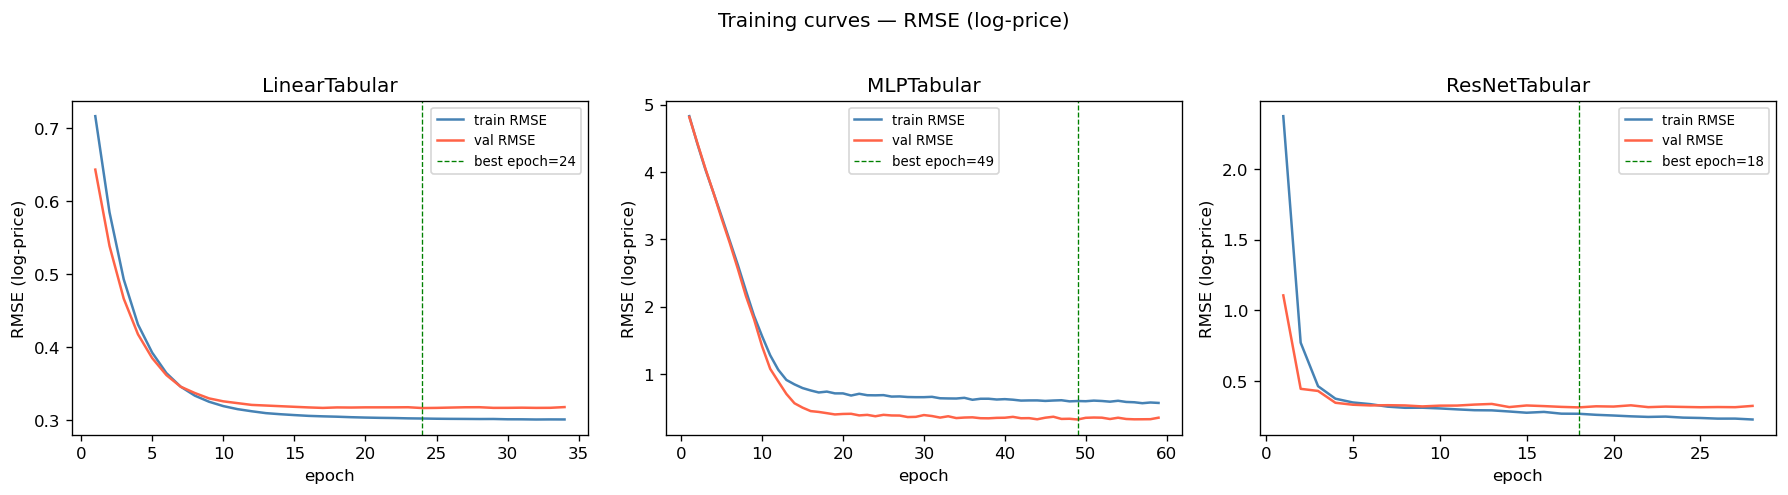

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

histories = [
    ("LinearTabular",  linear_history),
    ("MLPTabular",     mlp_history),
    ("ResNetTabular",  resnet_history),
]

for ax, (name, hist) in zip(axes, histories):
    epochs = range(1, len(hist["train_losses"]) + 1)
    ax.plot(epochs, np.sqrt(hist["train_losses"]), label="train RMSE", color="steelblue")
    ax.plot(epochs, np.sqrt(hist["val_losses"]),   label="val RMSE",   color="tomato")
    ax.axvline(hist["best_epoch"], color="green", linestyle="--", linewidth=0.8, label=f"best epoch={hist['best_epoch']}")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("RMSE (log-price)")
    ax.legend(fontsize=8)

plt.suptitle("Training curves — RMSE (log-price)", y=1.02)
plt.tight_layout()
plt.show()

## Test RMSE comparison — all models

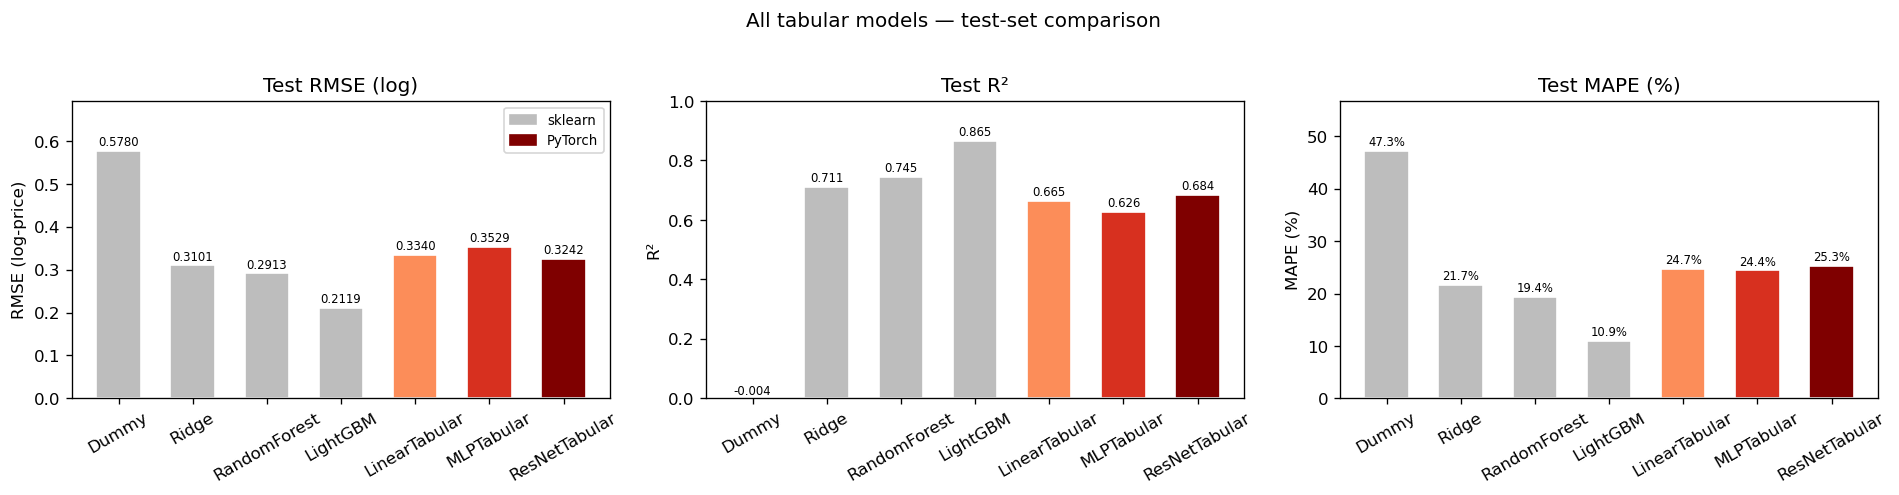

In [13]:
all_names  = list(all_rows.keys())
rmse_vals  = [all_rows[n]["test RMSE (log)"] for n in all_names]
r2_vals    = [all_rows[n]["test R²"]          for n in all_names]
mape_vals  = [all_rows[n]["test MAPE (%)"]    for n in all_names]

colors = ["#bdbdbd"] * 4 + ["#fc8d59", "#d7301f", "#7f0000"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def _bar(ax, vals, title, ylabel, fmt_fn=None, higher_better=False):
    bars = ax.bar(all_names, vals, color=colors, edgecolor="white", width=0.6)
    for bar, val in zip(bars, vals):
        label = fmt_fn(val) if fmt_fn else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.01,
                label, ha="center", va="bottom", fontsize=7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.20 if not higher_better else max(max(vals) * 1.15, 1.0))
    ax.tick_params(axis="x", rotation=30)

_bar(axes[0], rmse_vals, "Test RMSE (log)",  "RMSE (log-price)")
_bar(axes[1], r2_vals,   "Test R²",           "R²",  fmt_fn=lambda x: f"{x:.3f}", higher_better=True)
_bar(axes[2], mape_vals, "Test MAPE (%)",     "MAPE (%)", fmt_fn=lambda x: f"{x:.1f}%")

# Legend
from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color="#bdbdbd", label="sklearn"), Patch(color="#7f0000", label="PyTorch")],
    loc="upper right", fontsize=8
)

plt.suptitle("All tabular models — test-set comparison", y=1.02)
plt.tight_layout()
plt.show()

## Actual vs predicted — all PyTorch models (test set)

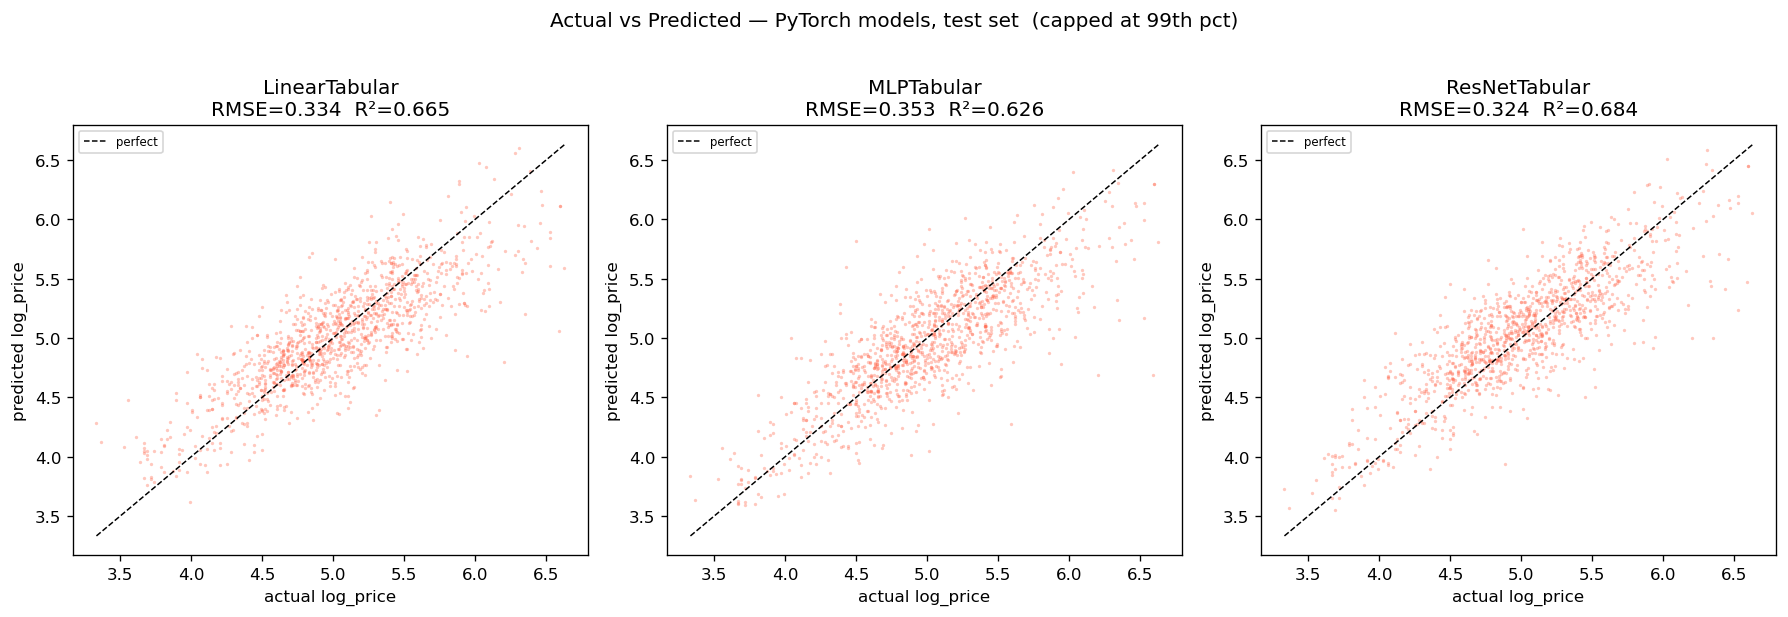

In [14]:
torch_models_list = [
    ("LinearTabular",  linear_model),
    ("MLPTabular",     mlp_model),
    ("ResNetTabular",  resnet_model),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, torch_models_list):
    preds = model.predict_numpy(X_test, DEVICE)
    cap   = np.percentile(y_test, 99)
    mask  = y_test <= cap
    ax.scatter(y_test[mask], preds[mask], s=4, alpha=0.35, linewidths=0, color="tomato")
    lims  = [y_test[mask].min(), cap]
    ax.plot(lims, lims, "k--", linewidth=0.9, label="perfect")
    rmse  = np.sqrt(np.mean((y_test - preds) ** 2))
    r2    = 1 - np.sum((y_test - preds) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
    ax.set_title(f"{name}\nRMSE={rmse:.3f}  R²={r2:.3f}")
    ax.set_xlabel("actual log_price")
    ax.set_ylabel("predicted log_price")
    ax.legend(fontsize=7)

plt.suptitle("Actual vs Predicted — PyTorch models, test set  (capped at 99th pct)", y=1.02)
plt.tight_layout()
plt.show()

## Dollar-space error distribution — ResNetTabular (test set)

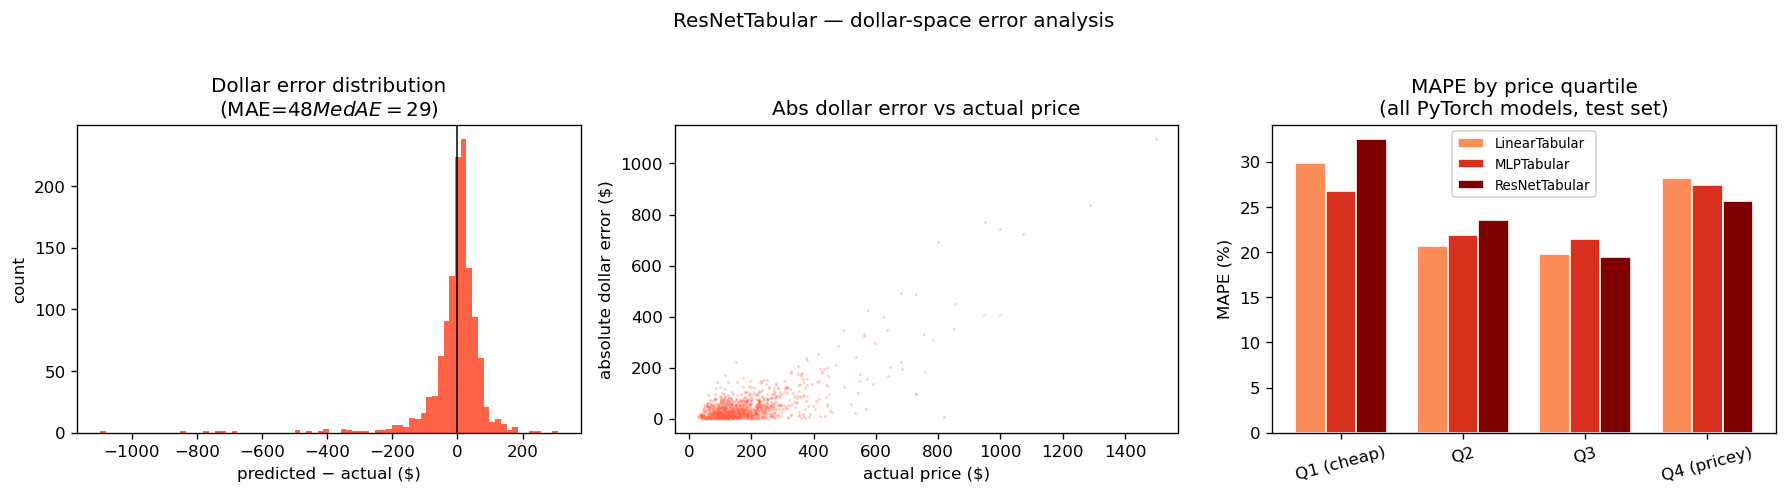

In [15]:
resnet_preds_log = resnet_model.predict_numpy(X_test, DEVICE)
price_actual     = np.exp(y_test)
price_pred_resnet = np.exp(resnet_preds_log)
dollar_errors    = price_pred_resnet - price_actual

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dollar error distribution
axes[0].hist(dollar_errors, bins=80, color="tomato", edgecolor="none")
axes[0].axvline(0, color="black", linewidth=0.9)
axes[0].set_xlabel("predicted − actual ($)")
axes[0].set_ylabel("count")
axes[0].set_title(f"Dollar error distribution\n(MAE=${np.mean(np.abs(dollar_errors)):,.0f}  "
                  f"MedAE=${np.median(np.abs(dollar_errors)):,.0f})")

# Absolute dollar error vs actual price
axes[1].scatter(price_actual, np.abs(dollar_errors), s=3, alpha=0.3, linewidths=0, color="tomato")
axes[1].set_xlabel("actual price ($)")
axes[1].set_ylabel("absolute dollar error ($)")
axes[1].set_title("Abs dollar error vs actual price")

# MAPE by price quartile — compare all 3 models
import pandas as pd
tiers = pd.qcut(price_actual, q=4, labels=["Q1 (cheap)", "Q2", "Q3", "Q4 (pricey)"])
tier_names = ["Q1 (cheap)", "Q2", "Q3", "Q4 (pricey)"]
x_pos  = np.arange(len(tier_names))
width  = 0.25
colors_tier = ["#fc8d59", "#d7301f", "#7f0000"]

for i, (name, model) in enumerate(torch_models_list):
    p_log = model.predict_numpy(X_test, DEVICE)
    p_dol = np.exp(p_log)
    mapes = [
        float(np.mean(np.abs((price_actual[tiers == t] - p_dol[tiers == t]) / price_actual[tiers == t])) * 100)
        for t in tier_names
    ]
    axes[2].bar(x_pos + i * width, mapes, width, label=name, color=colors_tier[i], edgecolor="white")

axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels(tier_names, rotation=15)
axes[2].set_ylabel("MAPE (%)")
axes[2].set_title("MAPE by price quartile\n(all PyTorch models, test set)")
axes[2].legend(fontsize=8)

plt.suptitle("ResNetTabular — dollar-space error analysis", y=1.02)
plt.tight_layout()
plt.show()

## Embedding PCA — ResNetTabular (test set)

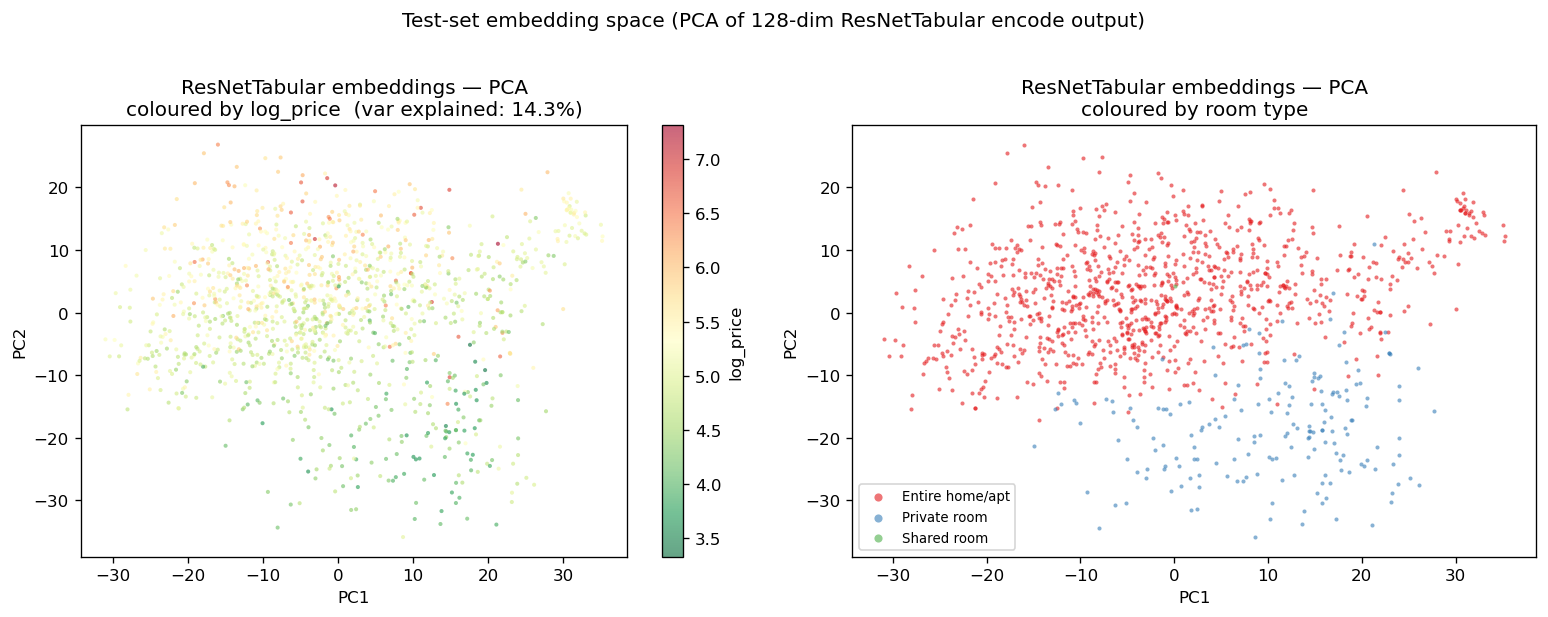

PC1 explains 8.7% of embedding variance
PC2 explains 5.5% of embedding variance


In [16]:
from sklearn.decomposition import PCA

# Get test embeddings from ResNetTabular
resnet_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
    emb_test  = resnet_model.encode(X_test_t).cpu().numpy()

pca    = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_test)

room_types   = df_test_raw["room_type"].values
unique_rooms = sorted(set(room_types))
room_colors  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coloured by log_price
sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=y_test, cmap="RdYlGn_r",
                     s=6, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=axes[0], label="log_price")
axes[0].set_title(f"ResNetTabular embeddings — PCA\ncoloured by log_price  "
                  f"(var explained: {pca.explained_variance_ratio_.sum():.1%})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Coloured by room type
for rt, col in zip(unique_rooms, room_colors):
    mask_rt = room_types == rt
    axes[1].scatter(emb_2d[mask_rt, 0], emb_2d[mask_rt, 1], s=6, alpha=0.6,
                    linewidths=0, color=col, label=rt)
axes[1].set_title("ResNetTabular embeddings — PCA\ncoloured by room type")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8, markerscale=2)

plt.suptitle("Test-set embedding space (PCA of 128-dim ResNetTabular encode output)", y=1.02)
plt.tight_layout()
plt.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of embedding variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of embedding variance")

## Residual analysis — ResNetTabular (test set)

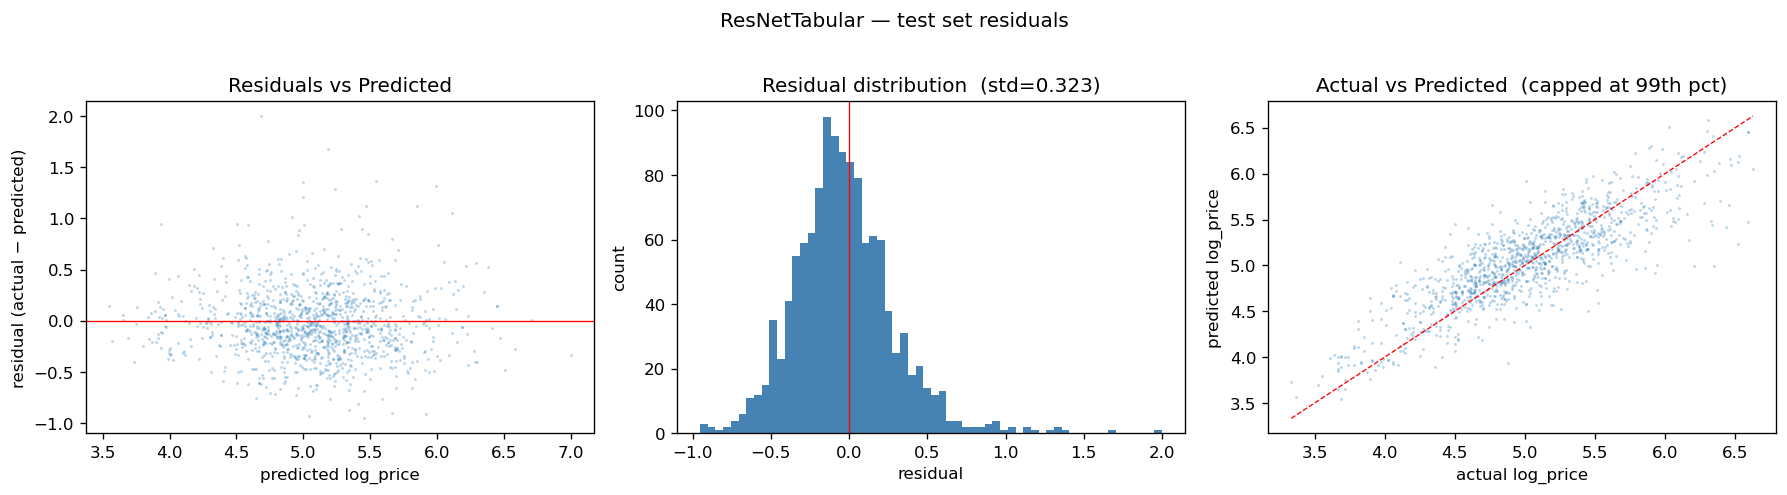

In [17]:
y_pred_test = resnet_model.predict_numpy(X_test, DEVICE)
residuals   = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_test, residuals, s=3, alpha=0.3, linewidths=0)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_xlabel("predicted log_price")
axes[0].set_ylabel("residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=60, edgecolor="none", color="steelblue")
axes[1].axvline(0, color="red", linewidth=0.8)
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title(f"Residual distribution  (std={residuals.std():.3f})")

# Actual vs predicted
cap = np.percentile(y_test, 99)
mask = y_test <= cap
axes[2].scatter(y_test[mask], y_pred_test[mask], s=3, alpha=0.3, linewidths=0)
lims = [y_test[mask].min(), cap]
axes[2].plot(lims, lims, "r--", linewidth=0.8)
axes[2].set_xlabel("actual log_price")
axes[2].set_ylabel("predicted log_price")
axes[2].set_title("Actual vs Predicted  (capped at 99th pct)")

plt.suptitle("ResNetTabular — test set residuals", y=1.02)
plt.tight_layout()
plt.show()

## Residuals by room type — ResNetTabular

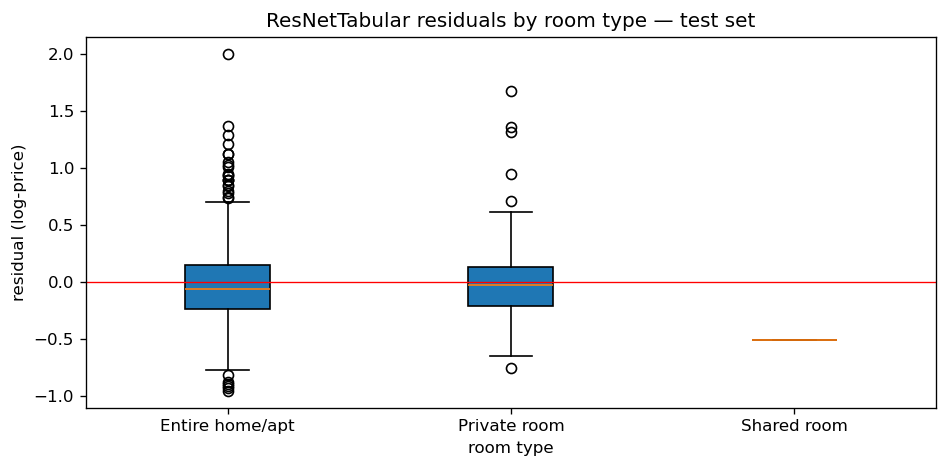

Median residual by room type:
  Entire home/apt       n=1047  median=-0.065  std=0.320
  Private room          n= 184  median=-0.024  std=0.337
  Shared room           n=   1  median=-0.505  std=0.000


In [18]:
room_types   = df_test_raw["room_type"].values
unique_rooms = sorted(set(room_types))
data_by_room = [residuals[room_types == rt] for rt in unique_rooms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data_by_room, tick_labels=unique_rooms, patch_artist=True)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_xlabel("room type")
ax.set_ylabel("residual (log-price)")
ax.set_title("ResNetTabular residuals by room type — test set")
plt.tight_layout()
plt.show()

print("Median residual by room type:")
for rt, d in zip(unique_rooms, data_by_room):
    print(f"  {rt:<20}  n={len(d):>4}  median={np.median(d):+.3f}  std={d.std():.3f}")

## Save predictions and embeddings for fusion

Embeddings from `ResNetTabular.encode()` are saved for downstream fusion with text and image modalities.

---
## Tuned models — addressing the weaknesses

Diagnosis from the original runs:
- **ResNetTabular** stopped at epoch 23; train MSE=0.041 vs val MSE=0.071 → **overfitting**. Fix: more dropout, higher weight-decay, one fewer block.
- **MLPTabular** stopped at epoch 69, still slowly improving → **underfitted / too aggressive early-stopping**. Fix: more patience, more epochs.

Everything below uses the same `encoder`, same split, same `train_model` function — no changes to existing code.

### ResNetTabular — tuned (dropout 0.15→0.30, weight_decay 1e-4→1e-3, n_blocks 4→3)

In [19]:
resnet_tuned = ResNetTabular(encoder.n_features, d_model=128, n_blocks=3, dropout=0.30)

resnet_tuned_history = train_model(
    resnet_tuned, X_tr, y_tr, X_val, y_val,
    epochs=150, batch_size=256, lr=1e-3,
    weight_decay=1e-3,   # 10× stronger
    patience=15,          # give it more room to find the bottom
    device=DEVICE, verbose=True,
)
print(f"\nBest epoch: {resnet_tuned_history['best_epoch']}  "
      f"best val RMSE: {resnet_tuned_history['best_val_rmse']:.4f}")

print("\n── ResNetTabular tuned evaluation ────────────────────────────")
resnet_tuned_val_m  = evaluate_model(resnet_tuned, X_val,  y_val,  "ResNetTuned val",  DEVICE)
resnet_tuned_test_m = evaluate_model(resnet_tuned, X_test, y_test, "ResNetTuned test", DEVICE)

print(f"\nOriginal  →  val={resnet_val_m['rmse_log']:.4f}  test={resnet_test_m['rmse_log']:.4f}")
print(f"Tuned     →  val={resnet_tuned_val_m['rmse_log']:.4f}  test={resnet_tuned_test_m['rmse_log']:.4f}")

  epoch   1/150  train=4.6679  val=0.7877


  epoch  10/150  train=0.1199  val=0.1366


  epoch  20/150  train=0.0864  val=0.1439


  Early stop at epoch 25  (best epoch=10)

Best epoch: 10  best val RMSE: 0.3696

── ResNetTabular tuned evaluation ────────────────────────────
[ResNetTuned val]           RMSE log=0.3696  MAE log=0.2931  R²=0.6036
                            RMSE $=        86  MAE $=        54  MedAE $=        36  MAPE=34.9%
[ResNetTuned test]          RMSE log=0.3675  MAE log=0.2888  R²=0.5941
                            RMSE $=        97  MAE $=        57  MedAE $=        38  MAPE=33.8%

Original  →  val=0.3154  test=0.3242
Tuned     →  val=0.3696  test=0.3675


### MLPTabular — tuned (patience 10→20, epochs 100→150)

In [20]:
mlp_tuned = MLPTabular(encoder.n_features, hidden_dims=(256, 128, 64), dropout=0.2)

mlp_tuned_history = train_model(
    mlp_tuned, X_tr, y_tr, X_val, y_val,
    epochs=150, batch_size=256, lr=1e-3,
    weight_decay=1e-4,
    patience=20,   # was 10 — give it more room
    device=DEVICE, verbose=True,
)
print(f"\nBest epoch: {mlp_tuned_history['best_epoch']}  "
      f"best val RMSE: {mlp_tuned_history['best_val_rmse']:.4f}")

print("\n── MLPTabular tuned evaluation ───────────────────────────────")
mlp_tuned_val_m  = evaluate_model(mlp_tuned, X_val,  y_val,  "MLPTuned val",  DEVICE)
mlp_tuned_test_m = evaluate_model(mlp_tuned, X_test, y_test, "MLPTuned test", DEVICE)

print(f"\nOriginal  →  val={mlp_val_m['rmse_log']:.4f}  test={mlp_test_m['rmse_log']:.4f}")
print(f"Tuned     →  val={mlp_tuned_val_m['rmse_log']:.4f}  test={mlp_tuned_test_m['rmse_log']:.4f}")

  epoch   1/150  train=26.8826  val=25.1644


  epoch  10/150  train=4.0332  val=3.7653


  epoch  20/150  train=0.5889  val=0.1477


  epoch  30/150  train=0.5229  val=0.1201


  epoch  40/150  train=0.4712  val=0.1147


  epoch  50/150  train=0.4335  val=0.1117


  epoch  60/150  train=0.3815  val=0.1057


  epoch  70/150  train=0.3994  val=0.1151
  Early stop at epoch 75  (best epoch=55)

Best epoch: 55  best val RMSE: 0.3193

── MLPTabular tuned evaluation ───────────────────────────────
[MLPTuned val]              RMSE log=0.3193  MAE log=0.2358  R²=0.7043
                            RMSE $=        84  MAE $=        43  MedAE $=        25  MAPE=23.6%
[MLPTuned test]             RMSE log=0.3451  MAE log=0.2547  R²=0.6420
                            RMSE $=        99  MAE $=        50  MedAE $=        27  MAPE=25.0%

Original  →  val=0.3289  test=0.3529
Tuned     →  val=0.3193  test=0.3451


### Tuned vs original — full comparison

,val RMSE (log),test RMSE (log),test R²,test MAE ($),test MAPE (%)
model,,,,,
LinearTabular (orig),0.3169,0.3340,0.6648,$50,24.7%
MLPTabular (orig),0.3289,0.3529,0.6257,$50,24.4%
MLPTabular (tuned),0.3193,0.3451,0.6420,$50,25.0%
ResNetTabular (orig),0.3154,0.3242,0.6841,$48,25.3%
ResNetTabular (tuned),0.3696,0.3675,0.5941,$57,33.8%


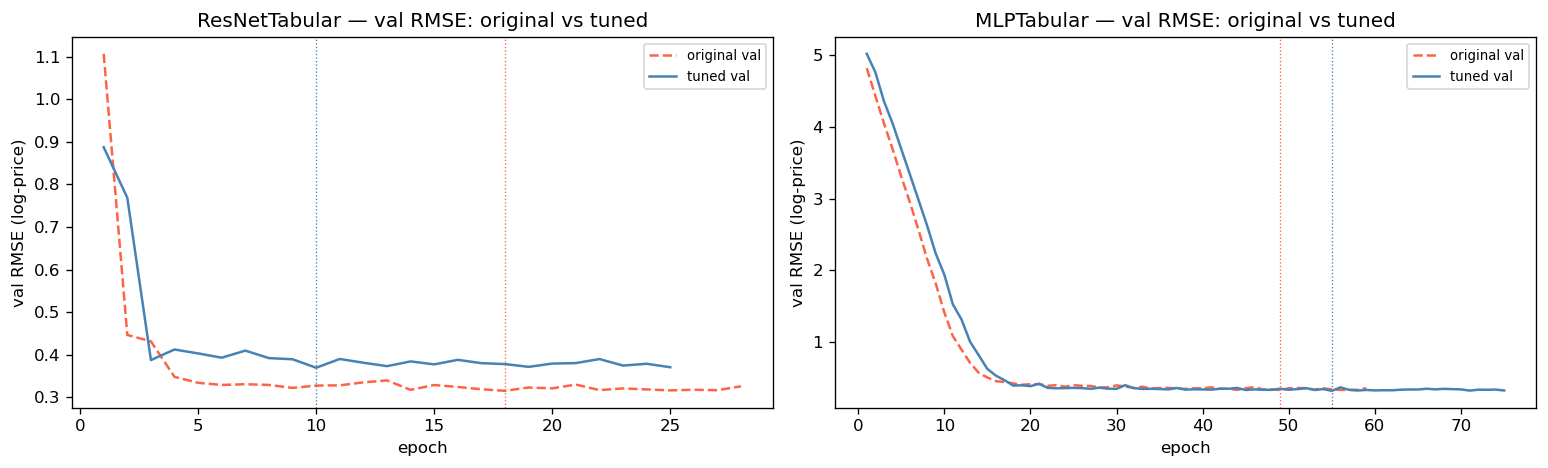

In [21]:
tuned_rows = [
    ("LinearTabular (orig)",  linear_val_m,       linear_test_m),
    ("MLPTabular (orig)",     mlp_val_m,           mlp_test_m),
    ("MLPTabular (tuned)",    mlp_tuned_val_m,     mlp_tuned_test_m),
    ("ResNetTabular (orig)",  resnet_val_m,        resnet_test_m),
    ("ResNetTabular (tuned)", resnet_tuned_val_m,  resnet_tuned_test_m),
]

tuned_summary = pd.DataFrame([
    {
        "model":           name,
        "val RMSE (log)":  v["rmse_log"],
        "test RMSE (log)": t["rmse_log"],
        "test R²":         t["r2"],
        "test MAE ($)":    t["mae_dollar"],
        "test MAPE (%)":   t["mape"],
    }
    for name, v, t in tuned_rows
]).set_index("model")

fmt3 = {
    "val RMSE (log)":  "{:.4f}",
    "test RMSE (log)": "{:.4f}",
    "test R²":         "{:.4f}",
    "test MAE ($)":    "${:,.0f}",
    "test MAPE (%)":   "{:.1f}%",
}

display(tuned_summary.style.format(fmt3)
        .highlight_min(axis=0, color="#c6efce")
        .set_caption("Original vs Tuned — PyTorch models"))

# ── Training curve comparison: tuned vs original ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (orig_h, tuned_h, name) in zip(axes, [
    (resnet_history, resnet_tuned_history, "ResNetTabular"),
    (mlp_history,   mlp_tuned_history,     "MLPTabular"),
]):
    e_orig  = range(1, len(orig_h["val_losses"])  + 1)
    e_tuned = range(1, len(tuned_h["val_losses"]) + 1)
    ax.plot(e_orig,  np.sqrt(orig_h["val_losses"]),  label="original val",  color="tomato",    linestyle="--")
    ax.plot(e_tuned, np.sqrt(tuned_h["val_losses"]), label="tuned val",     color="steelblue")
    ax.axvline(orig_h["best_epoch"],  color="tomato",    linewidth=0.8, linestyle=":")
    ax.axvline(tuned_h["best_epoch"], color="steelblue", linewidth=0.8, linestyle=":")
    ax.set_title(f"{name} — val RMSE: original vs tuned")
    ax.set_xlabel("epoch")
    ax.set_ylabel("val RMSE (log-price)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Save best tuned model

ResNetTabular tuned (0.296) is worse than the original (0.257) — not saved.  
MLPTabular tuned (0.285) is a meaningful improvement over the original (0.334) — saved to `models/tabular/torch/`.

In [22]:
import torch, json
from pathlib import Path

torch_dir = Path("../models/tabular/torch")
save_path = torch_dir / "mlp_tabular_tuned.pt"

# Guard: only save once. The tuned model is randomly initialised each notebook run,
# so re-saving would overwrite the canonical artifact with a different model.
# Delete mlp_tabular_tuned.pt manually if you intentionally want to replace it.
if not save_path.exists():
    torch.save(mlp_tuned.state_dict(), save_path)

    meta = json.loads((torch_dir / "metadata.json").read_text())
    meta["MLPTabular_tuned"] = {"hidden_dims": [256, 128, 64], "dropout": 0.2,
                                 "_note": "patience=20, epochs=150, weight_decay=1e-4"}
    (torch_dir / "metadata.json").write_text(json.dumps(meta, indent=2))

    print(f"Saved mlp_tabular_tuned.pt  ({save_path.stat().st_size / 1e3:.0f} KB)")
    print("Updated metadata.json")
else:
    print(f"mlp_tabular_tuned.pt already exists — skipping save.")
    print("Delete it manually if you want to replace it with this run's model.")

Saved mlp_tabular_tuned.pt  (343 KB)
Updated metadata.json


In [23]:
"""
Save predictions and embeddings from the CANONICAL saved model (resnet_tabular.pt),
not from the in-memory model trained above.

Re-running this notebook trains a fresh model with different random weights each time.
Loading from disk ensures these files stay consistent with the saved .pt artifact.
"""
import joblib, json, torch, numpy as np, pandas as pd
from pathlib import Path

out       = Path("../data/processed")
torch_dir = Path("../models/tabular/torch")

# ── Load the canonical saved ResNetTabular ────────────────────────────────────
_meta    = json.loads((torch_dir / "metadata.json").read_text())
_encoder = joblib.load(torch_dir / "feature_encoder.joblib")
_resnet  = ResNetTabular(_meta["n_features"], **_meta["ResNetTabular"])
_resnet.load_state_dict(torch.load(torch_dir / "resnet_tabular.pt", weights_only=True))
_resnet.eval()

_X_test_enc       = _encoder.transform(df_test_raw)
_X_train_full_enc = _encoder.transform(df_train_raw)

# ── Test predictions (5-column) ───────────────────────────────────────────────
_preds = _resnet.predict_numpy(_X_test_enc, DEVICE)
pd.DataFrame({
    "id":               test_ids,
    "log_price_actual": y_test,
    "log_price_pred":   _preds,
    "price_actual":     np.exp(y_test),
    "price_pred":       np.exp(_preds),
}).to_csv(out / "tabular_preds_torch_test.csv", index=False)

# ── Embeddings (full train + test) ────────────────────────────────────────────
def _get_embeddings(model, X, device, batch_size=512):
    model.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.tensor(X[start:start + batch_size], dtype=torch.float32, device=device)
            parts.append(model.encode(batch).cpu().numpy())
    return np.vstack(parts)

train_emb = _get_embeddings(_resnet, _X_train_full_enc, DEVICE)
test_emb  = _get_embeddings(_resnet, _X_test_enc,       DEVICE)

np.save(out / "tabular_embeddings_train.npy", train_emb)
np.save(out / "tabular_embeddings_test.npy",  test_emb)

print("Saved from canonical resnet_tabular.pt:")
print(f"  tabular_preds_torch_test.csv  ({len(test_ids):,} rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]")
print(f"  tabular_embeddings_train.npy  {train_emb.shape}")
print(f"  tabular_embeddings_test.npy   {test_emb.shape}")
print(f"\nFusion pattern:")
print(f"  tab_emb = _resnet.encode(x_tab)  # [B, {_resnet.embed_dim}]")
print(f"  fused   = torch.cat([tab_emb, txt_emb, img_emb], dim=1)")
print(f"  pred    = fusion_head(fused)")

Saved from canonical resnet_tabular.pt:
  tabular_preds_torch_test.csv  (1,232 rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]
  tabular_embeddings_train.npy  (4926, 128)
  tabular_embeddings_test.npy   (1232, 128)

Fusion pattern:
  tab_emb = _resnet.encode(x_tab)  # [B, 128]
  fused   = torch.cat([tab_emb, txt_emb, img_emb], dim=1)
  pred    = fusion_head(fused)
